# Models 2 & 3 — Macro-Regime Extraction and Regime-Conditional TVP

**Model 2** estimates a latent risk-regime index from four observable macro signals
using a Kalman filter (local linear trend). **Model 3a** feeds that regime index back
into the TVP factor model from `tvp_kalman.ipynb` as an additional factor, testing
whether FUND alpha is regime-dependent.

| Model | State | Observation |
|-------|-------|-------------|
| 2 — Regime | `[level_t, trend_t]` | Composite macro signal (first PC of VIX, slope, credit spread, S&P momentum) |
| 3a — Conditional | `[alpha, beta_mkt, beta_smb, beta_hml, beta_mom, gamma_regime]` | `r_t - rf_t` with regime as exogenous factor |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pykalman import KalmanFilter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

---
## Part I — Model 2: Macro-Regime Extraction

### 1. Load and Standardize Macro Signals

In [2]:
DATA_PATH = "../data/engineered_data/combined_monthly.csv"

MACRO_COLS = ["vix", "slope_10y_2y", "baa_aaa_spread", "sp500_mom_12m"]
FACTOR_COLS = ["Mkt_RF", "SMB", "HML", "Mom"]

df = pd.read_csv(DATA_PATH, parse_dates=["month"])
df = df.set_index("month").sort_index()

# Excess returns
df["excess_ret"] = df["fund_ret"] - df["RF"]

# Standardize macro signals (z-score)
scaler = StandardScaler()
macro_z = pd.DataFrame(
    scaler.fit_transform(df[MACRO_COLS]),
    index=df.index,
    columns=MACRO_COLS,
)

# Flip signs so that higher = risk-on:
#   VIX: high = risk-off → flip
#   baa_aaa_spread: high = risk-off → flip
#   slope_10y_2y: high = expansion → keep
#   sp500_mom_12m: high = risk-on → keep
macro_z["vix"] *= -1
macro_z["baa_aaa_spread"] *= -1

print("Standardized macro signals (sign-adjusted so higher = risk-on):")
macro_z.describe().round(3)

Standardized macro signals (sign-adjusted so higher = risk-on):


,vix,slope_10y_2y,baa_aaa_spread,sp500_mom_12m
count,129.000,129.000,129.000,129.000
mean,-0.000,0.000,-0.000,0.000
std,1.004,1.004,1.004,1.004
min,-5.127,-2.352,-3.564,-2.399
25%,-0.329,-0.554,-0.611,-0.708
50%,0.288,-0.040,0.070,0.014
75%,0.717,0.776,0.888,0.582
max,1.306,2.045,1.433,3.213


### 2. Extract First Principal Component

PC1 explains 49.5% of macro variance

PC1 loadings (sign-adjusted inputs):
                   vix: -0.413
          slope_10y_2y: -0.247
        baa_aaa_spread: -0.611
         sp500_mom_12m: -0.628


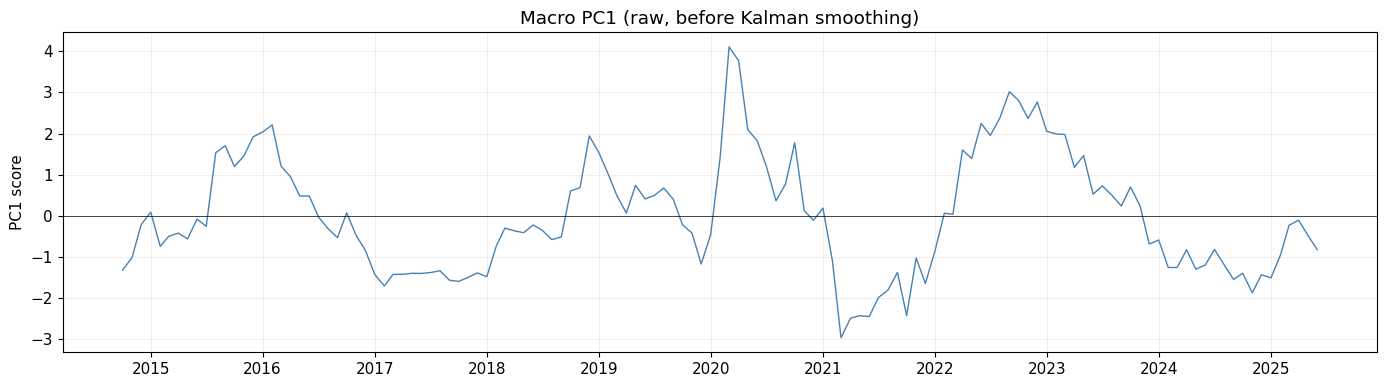

In [3]:
pca = PCA(n_components=1)
pc1 = pca.fit_transform(macro_z).flatten()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of macro variance")
print("\nPC1 loadings (sign-adjusted inputs):")
for col, loading in zip(MACRO_COLS, pca.components_[0]):
    print(f"  {col:>20s}: {loading:+.3f}")

# Store as a Series
macro_pc1 = pd.Series(pc1, index=df.index, name="macro_pc1")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(macro_pc1.index, macro_pc1, color="steelblue", lw=1)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Macro PC1 (raw, before Kalman smoothing)")
ax.set_ylabel("PC1 score")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

### 3. Local Linear Trend Kalman Filter on PC1

**State:** `[level_t, trend_t]`  
**Transition:** `level_t = level_{t-1} + trend_{t-1} + eta_level`  
&emsp;&emsp;&emsp;&emsp;&emsp;&ensp;`trend_t = trend_{t-1} + eta_trend`  
**Observation:** `pc1_t = level_t + eps_t`

This decomposes the macro signal into a smooth level (the regime index) and a
local trend (direction of regime change), filtering out observation noise.

In [4]:
# Local linear trend state-space model
transition = np.array([[1.0, 1.0],
                        [0.0, 1.0]])  # level + trend

observation = np.array([[1.0, 0.0]])  # observe level only

kf_regime = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    transition_matrices=transition,
    observation_matrices=observation,
    initial_state_mean=[pc1[0], 0.0],
    initial_state_covariance=np.eye(2) * 10,
    em_vars=["transition_covariance", "observation_covariance"],
)

# EM estimation
pc1_obs = pc1.reshape(-1, 1)
kf_regime = kf_regime.em(pc1_obs, n_iter=20)

# Filter and smooth
regime_filtered, regime_filtered_cov = kf_regime.filter(pc1_obs)
regime_smoothed, regime_smoothed_cov = kf_regime.smooth(pc1_obs)

print("EM-estimated noise:")
print(f"  Observation noise (sigma_eps):  {np.sqrt(kf_regime.observation_covariance[0,0]):.4f}")
print(f"  Level noise (sigma_level):      {np.sqrt(kf_regime.transition_covariance[0,0]):.4f}")
print(f"  Trend noise (sigma_trend):      {np.sqrt(kf_regime.transition_covariance[1,1]):.4f}")

EM-estimated noise:
  Observation noise (sigma_eps):  0.2642
  Level noise (sigma_level):      0.4938
  Trend noise (sigma_trend):      0.2499


In [5]:
# Extract smoothed regime index and trend
regime_index = pd.Series(regime_smoothed[:, 0], index=df.index, name="regime_index")
regime_trend = pd.Series(regime_smoothed[:, 1], index=df.index, name="regime_trend")
regime_se = pd.Series(
    np.sqrt(np.array([c[0, 0] for c in regime_smoothed_cov])),
    index=df.index, name="regime_se",
)

print("Regime index summary:")
print(regime_index.describe().round(3).to_string())

Regime index summary:
count    129.000
mean      -0.000
std        1.372
min       -2.587
25%       -1.194
50%       -0.203
75%        0.943
max        3.581


### 4. Regime Index Visualization

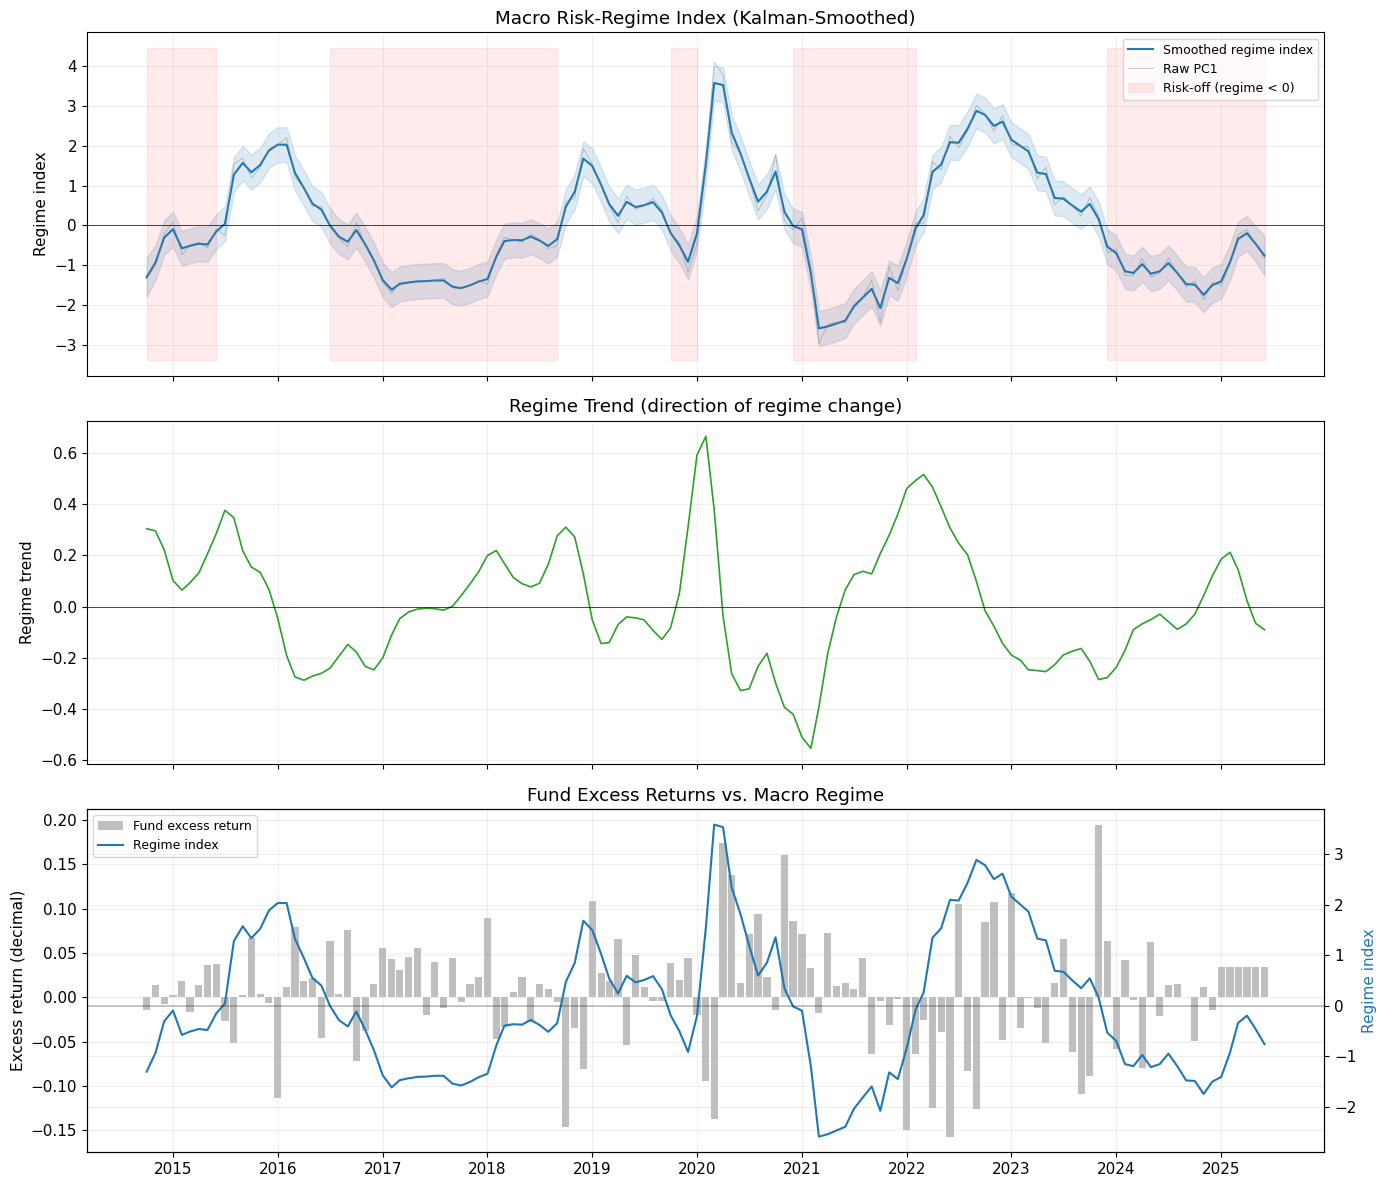

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Panel A: Regime index ---
ax = axes[0]
ax.plot(df.index, regime_index, color="#1f77b4", lw=1.5, label="Smoothed regime index")
ax.plot(df.index, macro_pc1, color="gray", lw=0.6, alpha=0.5, label="Raw PC1")
ax.fill_between(
    df.index,
    regime_index - 2 * regime_se,
    regime_index + 2 * regime_se,
    alpha=0.15, color="#1f77b4",
)
ax.axhline(0, color="black", lw=0.5)

# Shade risk-off periods (regime < 0)
ax.fill_between(
    df.index, ax.get_ylim()[0], ax.get_ylim()[1],
    where=regime_index < 0,
    alpha=0.08, color="red", label="Risk-off (regime < 0)",
)
ax.set_ylabel("Regime index")
ax.set_title("Macro Risk-Regime Index (Kalman-Smoothed)")
ax.legend(fontsize=9)

# --- Panel B: Regime trend ---
ax = axes[1]
ax.plot(df.index, regime_trend, color="#2ca02c", lw=1.2)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Regime trend")
ax.set_title("Regime Trend (direction of regime change)")

# --- Panel C: Regime index vs. fund excess returns ---
ax = axes[2]
ax.bar(df.index, df["excess_ret"], width=25, alpha=0.5, color="gray", label="Fund excess return")
ax2 = ax.twinx()
ax2.plot(df.index, regime_index, color="#1f77b4", lw=1.5, label="Regime index")
ax2.axhline(0, color="black", lw=0.3)
ax.set_ylabel("Excess return (decimal)")
ax2.set_ylabel("Regime index", color="#1f77b4")
ax.set_title("Fund Excess Returns vs. Macro Regime")

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

for a in axes:
    a.xaxis.set_major_locator(mdates.YearLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

### 5. Regime Correlation with Fund Performance

Fund excess returns by regime:
  Risk-ON  (regime >= 0):  n= 55   mean=+0.0014/mo  (+1.70%/yr)   vol=0.0840
  Risk-OFF (regime <  0):  n= 74   mean=+0.0103/mo  (+13.12%/yr)   vol=0.0421

  Correlation(regime_index, excess_ret): -0.077


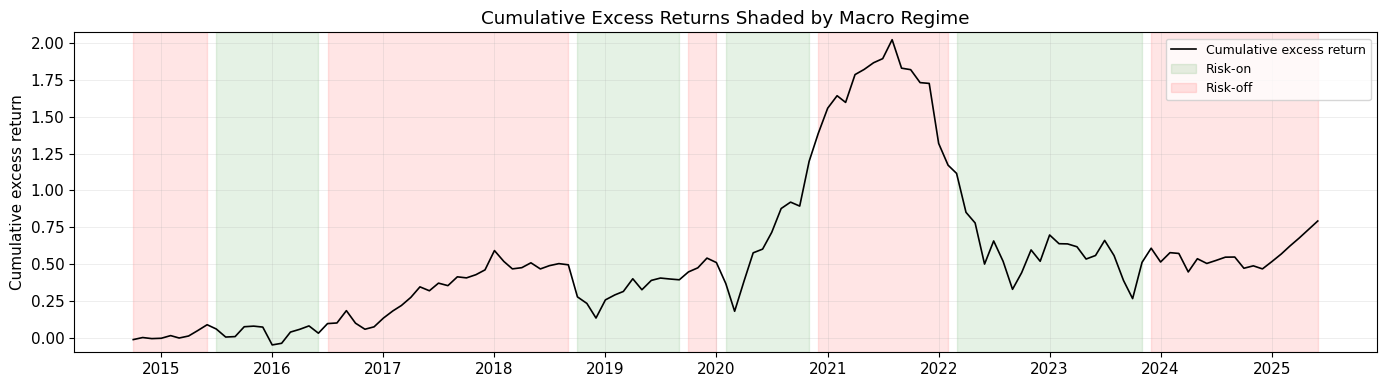

In [7]:
# Split returns by regime
risk_on = df["excess_ret"][regime_index >= 0]
risk_off = df["excess_ret"][regime_index < 0]

print("Fund excess returns by regime:")
print(f"  Risk-ON  (regime >= 0):  n={len(risk_on):3d}   mean={risk_on.mean():+.4f}/mo  ({((1+risk_on.mean())**12-1):+.2%}/yr)   vol={risk_on.std():.4f}")
print(f"  Risk-OFF (regime <  0):  n={len(risk_off):3d}   mean={risk_off.mean():+.4f}/mo  ({((1+risk_off.mean())**12-1):+.2%}/yr)   vol={risk_off.std():.4f}")
print(f"\n  Correlation(regime_index, excess_ret): {regime_index.corr(df['excess_ret']):.3f}")

# Cumulative returns by regime
fig, ax = plt.subplots(figsize=(14, 4))
cum_ret = (1 + df["excess_ret"]).cumprod() - 1
ax.plot(df.index, cum_ret, color="black", lw=1.2, label="Cumulative excess return")

# Shade by regime
ymin, ymax = cum_ret.min() - 0.05, cum_ret.max() + 0.05
ax.fill_between(
    df.index, ymin, ymax,
    where=regime_index >= 0, alpha=0.10, color="green", label="Risk-on",
)
ax.fill_between(
    df.index, ymin, ymax,
    where=regime_index < 0, alpha=0.10, color="red", label="Risk-off",
)
ax.set_ylim(ymin, ymax)
ax.set_ylabel("Cumulative excess return")
ax.set_title("Cumulative Excess Returns Shaded by Macro Regime")
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

### 6. Export Regime Index

In [8]:
regime_export = pd.DataFrame({
    "regime_index": regime_index,
    "regime_trend": regime_trend,
    "regime_se": regime_se,
    "macro_pc1_raw": macro_pc1,
})
regime_export.to_csv("regime_index.csv")
print(f"Exported {len(regime_export)} rows to kalman/regime_index.csv")

Exported 129 rows to kalman/regime_index.csv


---
## Part II — Model 3a: Regime-Conditional TVP Factor Attribution

Extends Model 1 by adding the smoothed regime index as a 5th factor:

```
r_t - rf_t = alpha_t + beta_mkt_t * MktRF_t + beta_smb_t * SMB_t
           + beta_hml_t * HML_t + beta_mom_t * Mom_t
           + gamma_t * regime_t + eps_t
```

If `gamma_t` is significantly nonzero, the fund's returns have a regime-dependent
component beyond what the standard factors capture.

### 7. Setup

In [9]:
# Build the augmented factor matrix
AUGMENTED_FACTORS = FACTOR_COLS + ["regime_index"]

df["regime_index"] = regime_index

cols_needed = ["excess_ret"] + FACTOR_COLS + ["regime_index"]
df_aug = df[cols_needed].dropna()

y = df_aug["excess_ret"].values
X_aug = df_aug[AUGMENTED_FACTORS].values
dates = df_aug.index

n_obs = len(y)
n_factors_aug = X_aug.shape[1]
n_states_aug = 1 + n_factors_aug  # alpha + 5 betas

print(f"Observations: {n_obs}  |  Factors: {n_factors_aug}  |  States: {n_states_aug}")
print(f"Window: {dates[0].strftime('%Y-%m')} to {dates[-1].strftime('%Y-%m')}")

Observations: 129  |  Factors: 5  |  States: 6
Window: 2014-10 to 2025-06


### 8. Static OLS with Regime Factor (Baseline)

In [10]:
X_ols_aug = sm.add_constant(X_aug)
ols_aug = sm.OLS(y, X_ols_aug).fit()
print(ols_aug.summary())

print(f"\nRegime coefficient: {ols_aug.params[-1]:.4f}  (p={ols_aug.pvalues[-1]:.3f})")
print(f"Alpha: {ols_aug.params[0]:.4f}/mo  ({(1+ols_aug.params[0])**12-1:.2%}/yr)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     133.9
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           5.02e-48
Time:                        13:08:57   Log-Likelihood:                 293.63
No. Observations:                 129   AIC:                            -575.3
Df Residuals:                     123   BIC:                            -558.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.002      0.656      0.5

### 9. TVP Kalman with Regime Factor

In [11]:
# Time-varying observation matrices
obs_matrices_aug = np.zeros((n_obs, 1, n_states_aug))
obs_matrices_aug[:, 0, 0] = 1.0
obs_matrices_aug[:, 0, 1:] = X_aug

# Initial state from OLS on first 12 months
init_window = min(12, n_obs)
X_init_aug = sm.add_constant(X_aug[:init_window])
ols_init_aug = sm.OLS(y[:init_window], X_init_aug).fit()
initial_state_aug = ols_init_aug.params
initial_cov_aug = np.diag(ols_init_aug.bse ** 2) * 10

print("Initial state (first 12-month OLS):")
for name, val in zip(["alpha"] + AUGMENTED_FACTORS, initial_state_aug):
    print(f"  {name:>15s}: {val:+.4f}")

Initial state (first 12-month OLS):
            alpha: -0.0004
           Mkt_RF: +0.4775
              SMB: +0.1482
              HML: +0.9685
              Mom: +0.8813
     regime_index: -0.0063


In [12]:
kf_aug = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_states_aug,
    transition_matrices=np.eye(n_states_aug),
    observation_matrices=obs_matrices_aug,
    initial_state_mean=initial_state_aug,
    initial_state_covariance=initial_cov_aug,
    em_vars=["transition_covariance", "observation_covariance"],
)

observations = y.reshape(-1, 1)
kf_aug = kf_aug.em(observations, n_iter=20)

print("EM-estimated observation noise (R):")
print(f"  sigma_eps = {np.sqrt(kf_aug.observation_covariance[0, 0]):.4f}")
print("\nEM-estimated state noise diagonal (sqrt of diag Q):")
for name, q in zip(["alpha"] + AUGMENTED_FACTORS, np.sqrt(np.diag(kf_aug.transition_covariance))):
    print(f"  {name:>15s}: {q:.6f}")

EM-estimated observation noise (R):
  sigma_eps = 0.0384

EM-estimated state noise diagonal (sqrt of diag Q):
            alpha: 0.041884
           Mkt_RF: 0.576246
              SMB: 0.800618
              HML: 0.699379
              Mom: 0.698986
     regime_index: 0.036025


In [13]:
# Filter and smooth
filtered_aug, filtered_cov_aug = kf_aug.filter(observations)
smoothed_aug, smoothed_cov_aug = kf_aug.smooth(observations)

state_names_aug = ["alpha"] + AUGMENTED_FACTORS

df_smoothed_aug = pd.DataFrame(smoothed_aug, index=dates, columns=state_names_aug)
smoothed_se_aug = np.sqrt(np.array([np.diag(c) for c in smoothed_cov_aug]))
df_smoothed_se_aug = pd.DataFrame(smoothed_se_aug, index=dates, columns=state_names_aug)

print("Smoothed state means (last 5 months):")
df_smoothed_aug.tail()

Smoothed state means (last 5 months):


,alpha,Mkt_RF,SMB,HML,Mom,regime_index
month,,,,,,
2025-02-01,0.001906,0.842899,0.333829,0.244098,0.439221,-0.010217
2025-03-01,-0.000194,0.804635,0.349777,0.257476,0.436843,-0.010292
2025-04-01,-0.003630,0.767487,0.355867,0.249072,0.422203,-0.010279
2025-05-01,-0.007106,0.730039,0.361871,0.240938,0.407414,-0.010269
2025-06-01,-0.005734,0.735671,0.373667,0.243208,0.407335,-0.010841


### 10. Regime Coefficient (gamma) Over Time

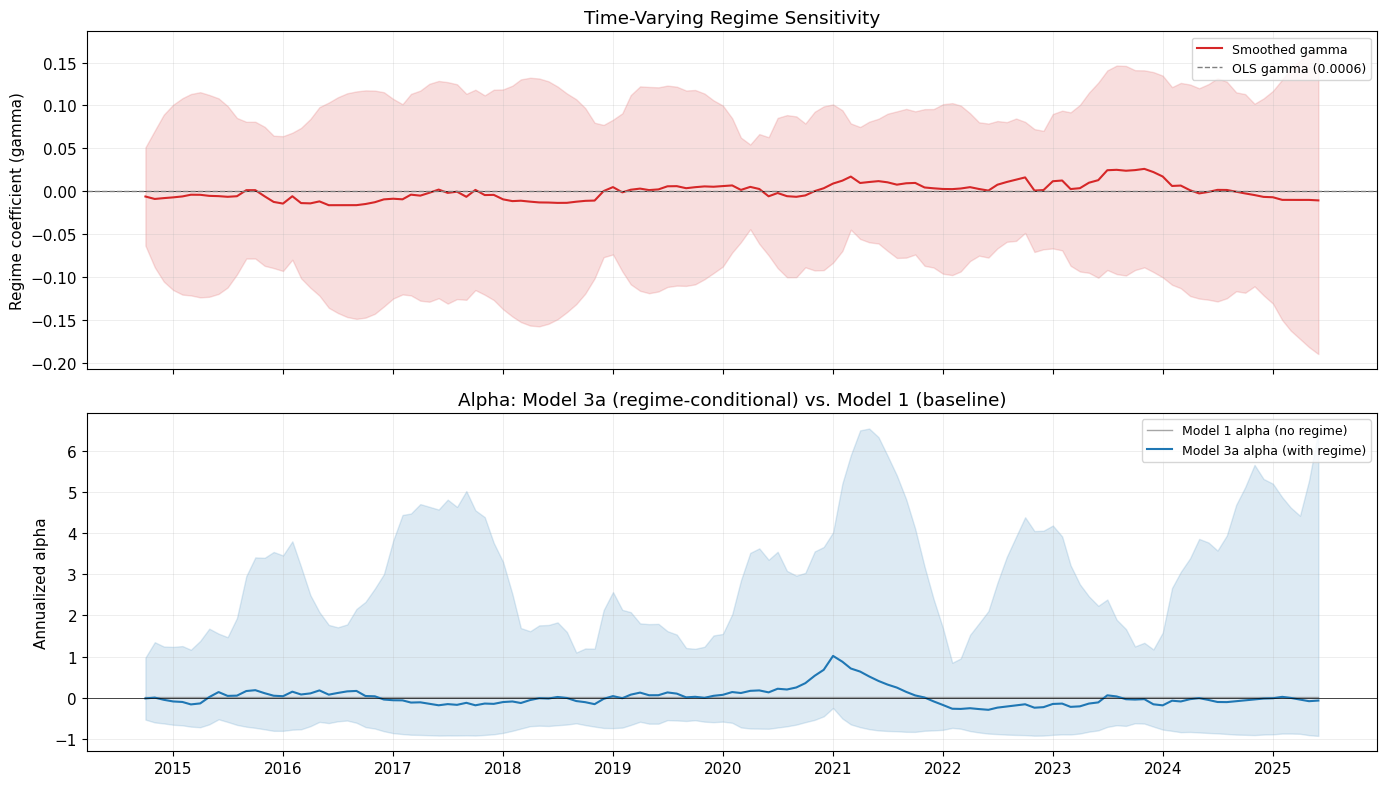

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Panel A: gamma_t ---
ax = axes[0]
ax.plot(dates, df_smoothed_aug["regime_index"], color="#d62728", lw=1.5, label="Smoothed gamma")
ax.fill_between(
    dates,
    df_smoothed_aug["regime_index"] - 2 * df_smoothed_se_aug["regime_index"],
    df_smoothed_aug["regime_index"] + 2 * df_smoothed_se_aug["regime_index"],
    alpha=0.15, color="#d62728",
)
ax.axhline(0, color="black", lw=0.5)
ax.axhline(ols_aug.params[-1], color="gray", ls="--", lw=1,
           label=f"OLS gamma ({ols_aug.params[-1]:.4f})")
ax.set_ylabel("Regime coefficient (gamma)")
ax.set_title("Time-Varying Regime Sensitivity")
ax.legend(fontsize=9)

# --- Panel B: alpha_t (Model 3a vs Model 1) ---
ax = axes[1]

# Load Model 1 alpha for comparison
try:
    m1 = pd.read_csv("tvp_kalman_results.csv", parse_dates=["month"], index_col="month")
    ax.plot(m1.index, (1 + m1["alpha"]) ** 12 - 1, color="gray", lw=1,
            alpha=0.7, label="Model 1 alpha (no regime)")
except FileNotFoundError:
    pass

annual_alpha_aug = (1 + df_smoothed_aug["alpha"]) ** 12 - 1
ax.plot(dates, annual_alpha_aug, color="#1f77b4", lw=1.5, label="Model 3a alpha (with regime)")
ax.fill_between(
    dates,
    ((1 + df_smoothed_aug["alpha"] - 2 * df_smoothed_se_aug["alpha"]) ** 12 - 1),
    ((1 + df_smoothed_aug["alpha"] + 2 * df_smoothed_se_aug["alpha"]) ** 12 - 1),
    alpha=0.15, color="#1f77b4",
)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Annualized alpha")
ax.set_title("Alpha: Model 3a (regime-conditional) vs. Model 1 (baseline)")
ax.legend(fontsize=9)

for a in axes:
    a.xaxis.set_major_locator(mdates.YearLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

### 11. All Betas — Model 3a

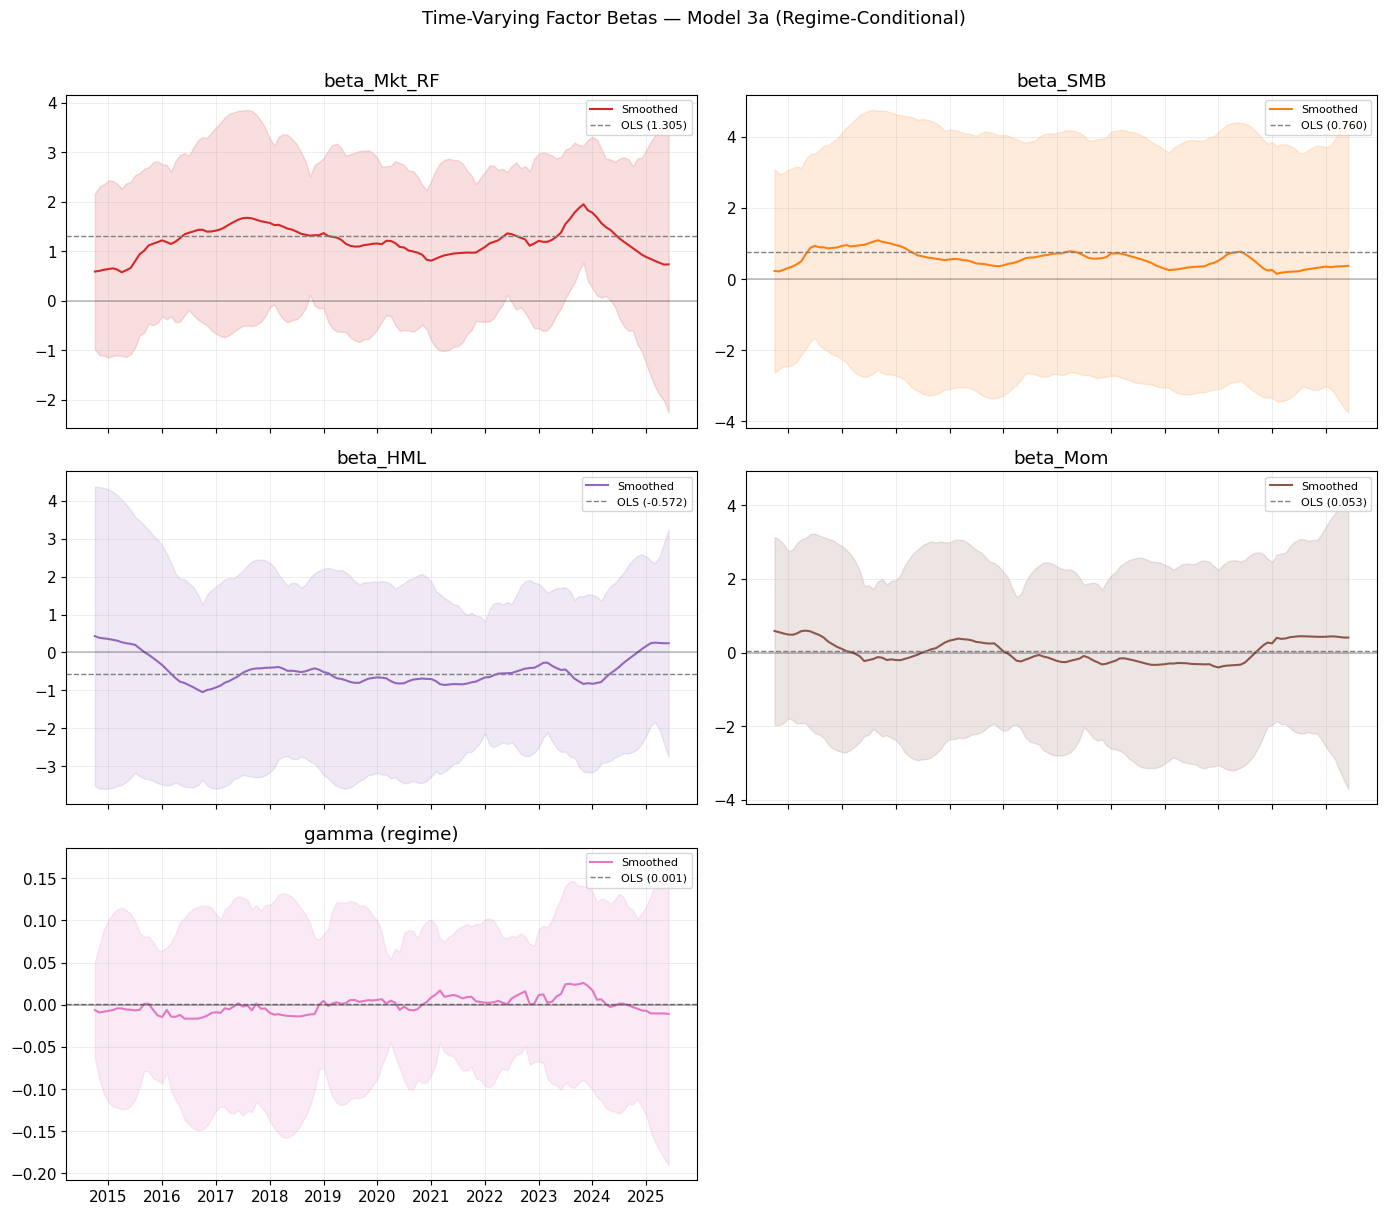

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

plot_factors = AUGMENTED_FACTORS  # Mkt_RF, SMB, HML, Mom, regime_index
colors = ["#d62728", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2"]

for ax, factor, color in zip(axes.flat[:len(plot_factors)], plot_factors, colors):
    ax.plot(dates, df_smoothed_aug[factor], color=color, lw=1.5, label="Smoothed")
    ax.fill_between(
        dates,
        df_smoothed_aug[factor] - 2 * df_smoothed_se_aug[factor],
        df_smoothed_aug[factor] + 2 * df_smoothed_se_aug[factor],
        alpha=0.15, color=color,
    )
    idx = 1 + AUGMENTED_FACTORS.index(factor)
    ax.axhline(ols_aug.params[idx], color="gray", ls="--", lw=1,
               label=f"OLS ({ols_aug.params[idx]:.3f})")
    ax.axhline(0, color="black", lw=0.3)
    display_name = "gamma (regime)" if factor == "regime_index" else f"beta_{factor}"
    ax.set_title(display_name)
    ax.legend(fontsize=8, loc="best")

# Hide unused subplot
axes.flat[-1].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Time-Varying Factor Betas — Model 3a (Regime-Conditional)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### 12. Diagnostics — Model 3a

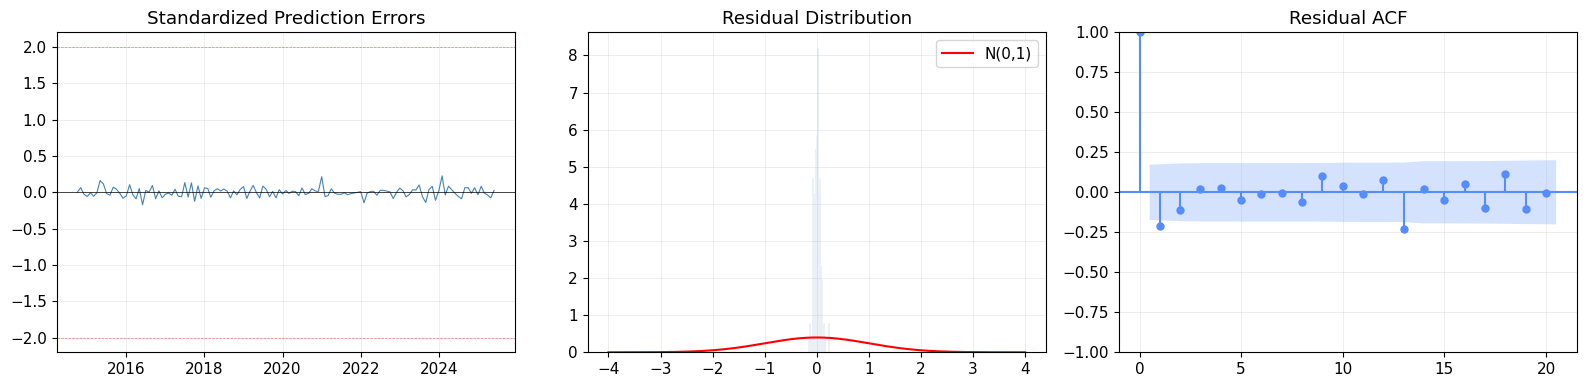

Ljung-Box test (H0: no serial correlation):
      lb_stat  lb_pvalue
6    8.079886   0.232309
12  11.080473   0.522035


In [16]:
# One-step-ahead predictions
y_pred_aug = np.array([
    obs_matrices_aug[t] @ filtered_aug[t]
    for t in range(n_obs)
]).flatten()

residuals_aug = y - y_pred_aug

pred_var_aug = np.array([
    (obs_matrices_aug[t] @ filtered_cov_aug[t] @ obs_matrices_aug[t].T
     + kf_aug.observation_covariance)[0, 0]
    for t in range(n_obs)
])
std_residuals_aug = residuals_aug / np.sqrt(pred_var_aug)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(dates, std_residuals_aug, lw=0.8, color="steelblue")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].axhline(2, color="red", ls="--", lw=0.5, alpha=0.5)
axes[0].axhline(-2, color="red", ls="--", lw=0.5, alpha=0.5)
axes[0].set_title("Standardized Prediction Errors")

axes[1].hist(std_residuals_aug, bins=20, density=True, alpha=0.7,
             color="steelblue", edgecolor="white")
xg = np.linspace(-4, 4, 200)
axes[1].plot(xg, 1/np.sqrt(2*np.pi) * np.exp(-xg**2/2), "r-", lw=1.5, label="N(0,1)")
axes[1].set_title("Residual Distribution")
axes[1].legend()

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_residuals_aug, ax=axes[2], lags=20, alpha=0.05)
axes[2].set_title("Residual ACF")

fig.tight_layout()
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(std_residuals_aug, lags=[6, 12], return_df=True)
print("Ljung-Box test (H0: no serial correlation):")
print(lb.to_string())

### 13. Model Comparison — All Three Models

In [17]:
# Model 3a likelihoods
kf_aug_loglik = kf_aug.loglikelihood(observations)
ols_aug_loglik = ols_aug.llf

# Load Model 1 results for comparison
# Re-run Model 1 OLS for consistent comparison
X_base = df_aug[FACTOR_COLS].values
X_ols_base = sm.add_constant(X_base)
ols_base = sm.OLS(y, X_ols_base).fit()

# Parameter counts
ols_base_k = len(FACTOR_COLS) + 1 + 1   # betas + const + sigma^2
ols_aug_k = len(AUGMENTED_FACTORS) + 1 + 1
kf_aug_k = n_states_aug + 1  # diagonal Q + R

rows = []
for name, ll, k in [
    ("Static OLS (4-factor)", ols_base.llf, ols_base_k),
    ("Static OLS (4-factor + regime)", ols_aug_loglik, ols_aug_k),
    ("TVP Kalman (4-factor + regime)", kf_aug_loglik, kf_aug_k),
]:
    rows.append({
        "Model": name,
        "Log-Likelihood": ll,
        "Free Params": k,
        "AIC": -2 * ll + 2 * k,
        "BIC": -2 * ll + k * np.log(n_obs),
    })

comparison = pd.DataFrame(rows).set_index("Model")
print(comparison.round(2).to_string())

# F-test for regime factor in OLS
from scipy import stats
f_stat = ((ols_base.ssr - ols_aug.ssr) / 1) / (ols_aug.ssr / ols_aug.df_resid)
f_pval = 1 - stats.f.cdf(f_stat, 1, ols_aug.df_resid)
print(f"\nF-test for regime factor (OLS): F={f_stat:.3f}, p={f_pval:.4f}")

                                Log-Likelihood  Free Params     AIC     BIC
Model                                                                      
Static OLS (4-factor)                   293.56            6 -575.11 -557.95
Static OLS (4-factor + regime)          293.63            7 -573.26 -553.24
TVP Kalman (4-factor + regime)          142.38            7 -270.76 -250.74

F-test for regime factor (OLS): F=0.143, p=0.7063


### 14. Parameter Comparison Across Models

In [18]:
# Compare static OLS (base) vs static OLS (aug) vs Kalman (aug)
params = ["alpha"] + FACTOR_COLS

comp_rows = []
for i, name in enumerate(params):
    row = {
        "Parameter": name,
        "OLS_4factor": ols_base.params[i],
        "OLS_4factor+regime": ols_aug.params[i],
        "Kalman_4factor+regime_mean": df_smoothed_aug[name].mean(),
        "Kalman_4factor+regime_std": df_smoothed_aug[name].std(),
    }
    comp_rows.append(row)

# Add regime coefficient
comp_rows.append({
    "Parameter": "gamma (regime)",
    "OLS_4factor": float("nan"),
    "OLS_4factor+regime": ols_aug.params[-1],
    "Kalman_4factor+regime_mean": df_smoothed_aug["regime_index"].mean(),
    "Kalman_4factor+regime_std": df_smoothed_aug["regime_index"].std(),
})

comp_df = pd.DataFrame(comp_rows).set_index("Parameter")
print("Parameter comparison across all models:")
print(comp_df.round(4).to_string())

Parameter comparison across all models:
                OLS_4factor  OLS_4factor+regime  Kalman_4factor+regime_mean  Kalman_4factor+regime_std
Parameter                                                                                             
alpha                0.0016              0.0016                      0.0002                     0.0159
Mkt_RF               1.3011              1.3054                      1.2052                     0.3017
SMB                  0.7585              0.7597                      0.5645                     0.2376
HML                 -0.5804             -0.5725                     -0.4826                     0.3661
Mom                  0.0492              0.0527                      0.0280                     0.3058
gamma (regime)          NaN              0.0006                     -0.0004                     0.0099


### 15. Export Model 3a Results

In [19]:
export_aug = df_smoothed_aug.copy()
for col in state_names_aug:
    export_aug[f"{col}_se"] = df_smoothed_se_aug[col]

export_aug["annualized_alpha"] = (1 + export_aug["alpha"]) ** 12 - 1
export_aug["excess_ret"] = y
export_aug["fitted"] = y_pred_aug
export_aug["residual"] = residuals_aug
export_aug["regime_level"] = regime_index

export_aug.to_csv("regime_conditional_results.csv")
print(f"Exported {len(export_aug)} rows to kalman/regime_conditional_results.csv")
export_aug.head()

Exported 129 rows to kalman/regime_conditional_results.csv


,alpha,Mkt_RF,SMB,HML,Mom,regime_index,alpha_se,Mkt_RF_se,SMB_se,HML_se,Mom_se,regime_index_se,annualized_alpha,excess_ret,fitted,residual,regime_level
month,,,,,,,,,,,,,,,,,
2014-10-01,-0.001247,0.590415,0.227825,0.428451,0.585316,-0.006314,0.029822,0.787140,1.430091,1.977993,1.276090,0.028642,-0.014861,-0.0142,-0.014379,0.000179,-1.302437
2014-11-01,0.000398,0.604203,0.215122,0.384217,0.550268,-0.009163,0.036694,0.850930,1.373526,1.987953,1.261014,0.039850,0.004781,0.0142,0.010928,0.003272,-0.930806
2014-12-01,-0.004099,0.625908,0.260087,0.370444,0.518719,-0.008187,0.036907,0.865150,1.358900,1.985420,1.217548,0.048690,-0.048096,-0.0073,-0.005875,-0.001425,-0.307823
2015-01-01,-0.007681,0.641654,0.310686,0.355109,0.489720,-0.007309,0.038515,0.895894,1.383094,1.975677,1.134648,0.054025,-0.088374,0.0023,0.005272,-0.002972,-0.094628
2015-02-01,-0.008835,0.655488,0.353745,0.333365,0.483291,-0.006206,0.039487,0.882376,1.383962,1.953337,1.159277,0.057281,-0.101021,0.0182,0.018511,-0.000311,-0.575883


In [ ]:
# Rolling regression uses the augmented (4-factor + regime) frame from Model 3a.
df_roll = df_aug

## 16. Rolling-Window OLS — A Middle Ground

Static OLS assumes the betas are *constant*; the Kalman filter lets every beta
drift *each* month. A **rolling-window OLS** sits between the two: the betas are
re-estimated on a trailing fixed window (24 and 36 months here). The coefficient
at month *t* uses the window **ending at** *t*, so it lines up directly with the
Kalman *smoothed* path. We also compute a true out-of-sample one-step-ahead
prediction (fit on months `[t-w, t-1]`, predict `t`) — the fair analogue of the
Kalman *filtered* one-step forecast.

In [ ]:
from rolling_regression import rolling_ols, rolling_one_step_pred, rolling_summary

FACTORS_ROLL = AUGMENTED_FACTORS
WINDOWS = [24, 36]
roll = {w: rolling_ols(df_roll, FACTORS_ROLL, w) for w in WINDOWS}
roll_pred = {w: rolling_one_step_pred(df_roll, FACTORS_ROLL, w) for w in WINDOWS}

for w in WINDOWS:
    first = roll[w].dropna(subset=["alpha"]).index[0]
    print(f"Rolling-{w}m: {roll[w]['alpha'].notna().sum()} estimates "
          f"({first:%Y-%m} onward)")

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
wstyle = {24: dict(color="#1f77b4", lw=1.5, alpha=0.6),
          36: dict(color="#d62728", lw=1.7, alpha=0.95)}

for ax, factor in zip(axes.flat, FACTORS_ROLL):
    idx = 1 + FACTORS_ROLL.index(factor)
    for w in WINDOWS:
        ax.plot(roll[w].index, roll[w][factor], label=f"Rolling-{w}m", **wstyle[w])
    ax.plot(df_smoothed_aug.index, df_smoothed_aug[factor], color="black", lw=1.1,
            ls=":", label="Kalman smoothed")
    ax.axhline(ols_aug.params[idx], color="gray", ls="--", lw=1,
               label=f"Static OLS ({ols_aug.params[idx]:.3f})")
    ax.axhline(0, color="black", lw=0.3)
    ax.set_title(f"Beta: {factor}")
    ax.legend(fontsize=8, loc="best")

# hide any unused axes
for ax in axes.flat[len(FACTORS_ROLL):]:
    ax.set_visible(False)
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Rolling-Window vs. Kalman vs. Static Betas — Model 3a (4-factor + regime)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
for w in WINDOWS:
    s = rolling_summary(roll[w], ols_aug.params, FACTORS_ROLL)
    print(f"\nRolling-{w}m vs. static OLS:")
    print(s.round(4).to_string())

In [ ]:
# One-step-ahead out-of-sample accuracy vs. the Kalman filter and static OLS.
def _rmse(r):
    r = np.asarray(r, float)
    r = r[~np.isnan(r)]
    return np.sqrt((r ** 2).mean())

_y = df_roll["excess_ret"].values
_tss = np.var(_y) * len(_y)
rows = [
    ("Static OLS (in-sample)", _rmse(ols_aug.resid), ols_aug.rsquared),
    ("TVP Kalman (1-step)", _rmse(residuals_aug),
     1 - np.nansum(np.asarray(residuals_aug) ** 2) / _tss),
]
for w in WINDOWS:
    r = roll_pred[w]["residual"].values
    m = ~np.isnan(r)
    rows.append((f"Rolling-{w}m (1-step OOS)", _rmse(r),
                 1 - np.nansum(r[m] ** 2) / (np.var(_y[m]) * m.sum())))

pred_compare = pd.DataFrame(rows, columns=["Model", "RMSE", "R2"]).set_index("Model")
print(pred_compare.round(4).to_string())

In [ ]:
rolling_export = []
for w in WINDOWS:
    e = roll[w].copy()
    e.insert(0, "window", w)
    e["fitted_oos"] = roll_pred[w]["fitted"]
    e["residual_oos"] = roll_pred[w]["residual"]
    e["excess_ret"] = df_roll["excess_ret"]
    e["annualized_alpha"] = (1 + e["alpha"]) ** 12 - 1
    e["regime_level"] = regime_index
    rolling_export.append(e)
rolling_export = pd.concat(rolling_export)
rolling_export.to_csv("rolling_regime_results.csv")
print(f"Exported {len(rolling_export)} rows to kalman/rolling_regime_results.csv")
rolling_export.dropna(subset=["alpha"]).head()